# 03. Character Network and Emotion Analysis

## Objective

The goal of this notebook is to analyze movie characters through two complementary perspectives:

- their interaction structure within the narrative
- their emotional profile based on screenplay text

Rather than analyzing the entire corpus as a single network, this notebook works at the **movie level**, since character interactions only make sense within the boundaries of a specific story.

## Why this matters

This stage moves the project from feature preparation into higher-level analytical modeling.

By combining graph-based interaction patterns with text-based emotional signals, we can begin to understand:

- which characters are structurally central
- which characters dominate the emotional tone of the story
- how narrative importance and emotional behavior relate to each other

## Expected output

By the end of this notebook, we expect to obtain:

- a movie-specific interaction graph
- network metrics for each character
- an initial emotional profile for each character
- a merged analytical table combining structural and emotional features

In [ ]:
from pathlib import Path
import sys

# Add project root to path to find src module
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
from src.utils.paths import PROJECT_ROOT

interim_path = PROJECT_ROOT / "data" / "interim" / "character_lines.parquet"
scene_path = PROJECT_ROOT / "data" / "processed" / "scene_dataset.parquet"
character_path = PROJECT_ROOT / "data" / "processed" / "character_dataset.parquet"

df_lines = pd.read_parquet(interim_path)
scene_df = pd.read_parquet(scene_path)
character_df = pd.read_parquet(character_path)

print("df_lines shape:", df_lines.shape)
print("scene_df shape:", scene_df.shape)
print("character_df shape:", character_df.shape)

## 2. Selecting a movie for detailed analysis

To ensure meaningful analysis, we focus on a single movie instead of working with the entire dataset at once.

Character interactions are inherently confined within individual movies, so analyzing them globally would mix unrelated narratives and produce misleading results.

By selecting a specific movie, we can:

- build an interpretable interaction graph
- validate the structure of relationships
- analyze character behavior in context

Once validated, this approach can be scaled across all movies.

In [3]:
movie_id = "10 Things I Hate About You_0147800"

In [4]:
movie_id = "10 Things I Hate About You_0147800"

df_movie = df_lines[df_lines["movie_id"] == movie_id].copy()
scene_movie = scene_df[scene_df["movie_id"] == movie_id].copy()
char_movie = character_df[character_df["movie_id"] == movie_id].copy()

print("Lines:", df_movie.shape)
print("Scenes:", scene_movie.shape)
print("Characters:", char_movie.shape)

char_movie.sort_values("rank_in_movie").head(10)

Lines: (1673, 11)
Scenes: (84, 6)
Characters: (18, 9)


,movie_id,character_name,total_lines,total_scenes,total_words,avg_words_per_line,avg_text_length,importance_score,rank_in_movie
554,10 Things I Hate About You_0147800,Kat Stratford,387,387,4187,10.819121,57.992248,311.6935,1.0
932,10 Things I Hate About You_0147800,Patrick Verona,324,324,3209,9.904321,53.941358,260.8045,2.0
1588,10 Things I Hate About You_0147800,Bianca Stratford,237,237,2555,10.780591,59.561181,190.8775,3.0
2144,10 Things I Hate About You_0147800,Cameron James,186,186,1844,9.913978,55.349462,149.7220,4.0
2781,10 Things I Hate About You_0147800,Michael Eckman,146,146,1695,11.609589,65.232877,117.6475,5.0
3262,10 Things I Hate About You_0147800,Joey Donner,123,123,1301,10.577236,57.528455,99.0505,6.0
4745,10 Things I Hate About You_0147800,Mandella,82,82,982,11.975610,67.243902,66.0910,7.0
4980,10 Things I Hate About You_0147800,Walter Stratford,77,77,698,9.064935,49.389610,61.9490,8.0
8611,10 Things I Hate About You_0147800,Chastity,36,36,441,12.250000,70.416667,29.0205,9.0
14337,10 Things I Hate About You_0147800,Mr Chapin,15,15,205,13.666667,71.933333,12.1025,10.0


## 3. Building character interaction edges

To construct the interaction network, we define an interaction as the co-presence of characters within the same scene.

For each scene, all pairs of characters are connected, and repeated co-occurrences increase the weight of the connection.

## Why this matters

This approach allows us to approximate:

- conversational interactions
- narrative proximity
- relationship strength between characters

The resulting graph will serve as the foundation for network analysis.

In [5]:
from itertools import combinations
import pandas as pd

edges = []

for _, row in scene_movie.iterrows():
    chars = row["characters_present"]
    
    if len(chars) < 2:
        continue
        
    for c1, c2 in combinations(sorted(chars), 2):
        edges.append((c1, c2))

edges_df = pd.DataFrame(edges, columns=["char_1", "char_2"])

edges_df.head()
edges_df.shape

(477, 2)

In [6]:
edges_weighted = (
    edges_df
    .groupby(["char_1", "char_2"])
    .size()
    .reset_index(name="weight")
    .sort_values("weight", ascending=False)
)

edges_weighted.head(10)

,char_1,char_2,weight
85,Kat Stratford,Patrick Verona,34
7,Bianca Stratford,Kat Stratford,23
29,Cameron James,Patrick Verona,21
0,Bianca Stratford,Cameron James,20
27,Cameron James,Michael Eckman,20
11,Bianca Stratford,Patrick Verona,18
79,Joey Donner,Patrick Verona,17
93,Michael Eckman,Patrick Verona,16
25,Cameron James,Kat Stratford,15
82,Kat Stratford,Mandella,12


## 4. Constructing the character interaction graph

Using the weighted edge list, we construct a graph where:

- nodes represent characters
- edges represent interactions
- edge weights capture interaction frequency

## Why this matters

Graph-based analysis allows us to move beyond simple counts and understand:

- which characters are structurally central
- how information or influence might flow
- which characters act as bridges between groups

In [7]:
import networkx as nx

G = nx.Graph()

for _, row in edges_weighted.iterrows():
    G.add_edge(
        row["char_1"],
        row["char_2"],
        weight=row["weight"]
    )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 18
Edges: 99


In [8]:
degree_centrality = nx.degree_centrality(G)
weighted_degree = dict(G.degree(weight="weight"))
betweenness = nx.betweenness_centrality(G)

In [9]:
graph_metrics = pd.DataFrame({
    "character_name": list(G.nodes()),
    "degree_centrality": [degree_centrality[n] for n in G.nodes()],
    "weighted_degree": [weighted_degree[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()]
})

graph_metrics.sort_values("weighted_degree", ascending=False).head(10)

,character_name,degree_centrality,weighted_degree,betweenness
1,Patrick Verona,0.941176,142,0.069278
0,Kat Stratford,0.882353,135,0.039254
2,Bianca Stratford,0.882353,122,0.053714
3,Cameron James,0.941176,116,0.083739
4,Michael Eckman,0.823529,90,0.028347
5,Joey Donner,0.882353,86,0.039254
6,Mandella,0.764706,58,0.031148
7,Chastity,0.764706,50,0.014151
8,Cowboy,0.705882,43,0.014134
10,Jock,0.764706,29,0.020731


In [10]:
char_analysis = char_movie.merge(
    graph_metrics,
    on="character_name",
    how="left"
)

char_analysis.sort_values("weighted_degree", ascending=False).head(10)

,movie_id,character_name,total_lines,total_scenes,total_words,avg_words_per_line,avg_text_length,importance_score,rank_in_movie,degree_centrality,weighted_degree,betweenness
1,10 Things I Hate About You_0147800,Patrick Verona,324,324,3209,9.904321,53.941358,260.8045,2.0,0.941176,142,0.069278
0,10 Things I Hate About You_0147800,Kat Stratford,387,387,4187,10.819121,57.992248,311.6935,1.0,0.882353,135,0.039254
2,10 Things I Hate About You_0147800,Bianca Stratford,237,237,2555,10.780591,59.561181,190.8775,3.0,0.882353,122,0.053714
3,10 Things I Hate About You_0147800,Cameron James,186,186,1844,9.913978,55.349462,149.7220,4.0,0.941176,116,0.083739
4,10 Things I Hate About You_0147800,Michael Eckman,146,146,1695,11.609589,65.232877,117.6475,5.0,0.823529,90,0.028347
5,10 Things I Hate About You_0147800,Joey Donner,123,123,1301,10.577236,57.528455,99.0505,6.0,0.882353,86,0.039254
6,10 Things I Hate About You_0147800,Mandella,82,82,982,11.975610,67.243902,66.0910,7.0,0.764706,58,0.031148
8,10 Things I Hate About You_0147800,Chastity,36,36,441,12.250000,70.416667,29.0205,9.0,0.764706,50,0.014151
11,10 Things I Hate About You_0147800,Cowboy,11,11,198,18.000000,100.000000,8.8990,12.0,0.705882,43,0.014134
12,10 Things I Hate About You_0147800,Jock,11,11,133,12.090909,67.454545,8.8665,13.0,0.764706,29,0.020731


The network structure aligns strongly with narrative expectations.

Main characters such as Kat Stratford, Patrick Verona, and Bianca Stratford dominate both in importance score and interaction strength.

However, differences emerge between narrative importance and structural roles:

- Patrick Verona appears as the most connected character in the network
- Kat Stratford remains the most narratively dominant character
- Cameron James acts as a bridge between different character groups

These findings demonstrate that combining network analysis with narrative metrics provides a richer understanding of character roles.

## 5. Character emotion analysis using transformers

To capture richer emotional signals, we use a pre-trained transformer model for emotion classification.

This approach allows us to detect nuanced emotional patterns beyond simple keyword matching.

## Model

We use a lightweight transformer fine-tuned for emotion detection:

- DistilRoBERTa-based
- trained on emotion classification tasks
- capable of detecting multiple emotional categories

## Why this matters

This enables us to:

- capture subtle emotional differences
- build more realistic character profiles
- connect emotional behavior with narrative structure

In [11]:
from transformers import pipeline

emotion_pipeline = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    return_all_scores=True
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 32658.65it/s]
RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
df_dialog = df_movie[df_movie["label"] == "dialog"].copy()

# sample para probar primero
df_sample = df_dialog.sample(200, random_state=42).copy()

print(df_sample.shape)

(200, 11)


### 5.1 Reconstructing cleaned text for emotion analysis

The processed scene and character datasets were saved after aggregation, but the original line-level dataset used for emotion analysis does not yet include the normalized text field.

Before applying the transformer model, we recreate the cleaned version of the dialogue text at the line level.

## Why this matters

Emotion classification is sensitive to noisy text. Rebuilding `clean_text` ensures that the model receives more consistent input while preserving the original dialogue content for reference.

In [13]:
import re

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # Normalize quotes
    text = text.replace("’", "'").replace("“", '"').replace("”", '"')

    # Fix common OCR issues in contractions
    text = text.replace("'1", "'")
    text = re.sub(r"(?<=[a-zA-Z])1(?=[a-zA-Z])", "", text)

    # Remove strange characters but keep basic punctuation
    text = re.sub(r"[^a-zA-Z0-9\s\.\,\!\?\']", " ", text)

    # Lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


df_movie["clean_text"] = df_movie["text"].apply(clean_text)

df_dialog = df_movie[df_movie["label"] == "dialog"].copy()
df_sample = df_dialog.sample(200, random_state=42).copy()

print("df_movie shape:", df_movie.shape)
print("df_dialog shape:", df_dialog.shape)
print("df_sample shape:", df_sample.shape)

df_sample[["text", "clean_text"]].head()

df_movie shape: (1673, 12)
df_dialog shape: (944, 12)
df_sample shape: (200, 12)


,text,clean_text
747,Fine. I see that I'm a prisoner in my own ho...,fine. i see that i'm a prisoner in my own hous...
1082,"Lookin' good, ladies.","lookin' good, ladies."
2040,(continuing) Maybe two.,continuing maybe two.
626,Where?,where?
639,Eber's Deep Conditioner every two days. And ...,eber's deep conditioner every two days. and i ...


### 5.2 Running the transformer model on a small batch

Before processing the full dialogue sample, we first test the transformer on a very small batch of lines.

This helps us verify:

- that the model runs successfully
- the exact format of its output
- the emotion labels returned by the classifier

## Why this matters

Transformer pipelines usually return nested prediction objects.  
Understanding the exact output structure is necessary before converting predictions into a clean tabular format for character-level analysis.

In [14]:

sample_texts = df_sample["clean_text"].tolist()

sample_predictions = emotion_pipeline(
    sample_texts[:10],
    truncation=True
)

print("Number of predictions:", len(sample_predictions))
print("\nFirst prediction:")
sample_predictions[0]

Number of predictions: 10

First prediction:


{'label': 'anger', 'score': 0.8631644248962402}

### 5.3 Recovering full emotion distributions

The initial transformer output only returns the top predicted emotion for each dialogue line.

However, for character profiling, we need the full probability distribution across all emotion categories.

Using full emotion scores is more informative because it allows us to:

- capture mixed emotional tones
- aggregate emotional tendencies across many dialogue lines
- compare characters using richer emotional profiles rather than a single dominant label

In [15]:
from transformers import pipeline

emotion_pipeline = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None
)

sample_predictions = emotion_pipeline(
    sample_texts[:3],
    truncation=True
)

print("Number of predictions:", len(sample_predictions))
print("\nFirst prediction:")
sample_predictions[0]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 56723.59it/s]
RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Number of predictions: 3

First prediction:


[{'label': 'anger', 'score': 0.8631644248962402},
 {'label': 'disgust', 'score': 0.0972181111574173},
 {'label': 'fear', 'score': 0.011909094639122486},
 {'label': 'sadness', 'score': 0.009111138992011547},
 {'label': 'neutral', 'score': 0.008101292885839939},
 {'label': 'surprise', 'score': 0.007900972850620747},
 {'label': 'joy', 'score': 0.0025950034614652395}]

### 5.4 Converting transformer outputs into emotion features

Now that we have access to the full emotion distribution for each dialogue line, we convert the model output into a tabular representation.

Each dialogue line will receive one score per emotion category, making it possible to:

- compare emotional tendencies across lines
- aggregate emotion scores by character
- build interpretable emotional profiles

## Why this matters

A tabular format is essential for downstream analysis, since it allows us to merge emotion features with:

- character-level importance metrics
- graph centrality metrics
- movie-level metadata

In [16]:
EMOTION_LABELS = ["anger", "disgust", "fear", "sadness", "neutral", "surprise", "joy"]

def scores_to_row(prediction_list):
    score_map = {item["label"]: item["score"] for item in prediction_list}
    return {label: score_map.get(label, 0.0) for label in EMOTION_LABELS}


# Run the model on the full sample
sample_predictions = emotion_pipeline(
    df_sample["clean_text"].tolist(),
    truncation=True
)

emotion_rows = [scores_to_row(pred) for pred in sample_predictions]
emotion_df = pd.DataFrame(emotion_rows)

df_sample_emotions = pd.concat(
    [df_sample.reset_index(drop=True), emotion_df.reset_index(drop=True)],
    axis=1
)

print("Emotion sample shape:", df_sample_emotions.shape)
df_sample_emotions[["character_name", "clean_text"] + EMOTION_LABELS].head()

Emotion sample shape: (200, 19)


,character_name,clean_text,anger,disgust,fear,sadness,neutral,surprise,joy
0,Bianca Stratford,fine. i see that i'm a prisoner in my own hous...,0.863164,0.097218,0.011909,0.009111,0.008101,0.007901,0.002595
1,Joey Donner,"lookin' good, ladies.",0.005274,0.006464,0.001370,0.017600,0.096501,0.028143,0.844649
2,Patrick Verona,continuing maybe two.,0.002673,0.003791,0.001503,0.003149,0.973055,0.011867,0.003962
3,Bianca Stratford,where?,0.018042,0.010134,0.006323,0.009181,0.373406,0.580151,0.002763
4,Bianca Stratford,eber's deep conditioner every two days. and i ...,0.018579,0.015065,0.007972,0.182429,0.618188,0.126315,0.031451


### 5.5 Aggregating emotion profiles by character

To understand emotional tendencies at the character level, we aggregate emotion scores across all dialogue lines.

For each character, we compute the average score for each emotion category.

## Why this matters

This allows us to move from individual dialogue lines to:

- consistent emotional patterns
- character-level emotional signatures
- comparative analysis across characters

These profiles will later be combined with network and importance metrics to build a complete characterization of each role.

In [17]:
emotion_by_character = (
    df_sample_emotions
    .groupby("character_name")[EMOTION_LABELS]
    .mean()
    .reset_index()
)

emotion_by_character.head(10)

,character_name,anger,disgust,fear,sadness,neutral,surprise,joy
0,Bianca Stratford,0.100032,0.044273,0.019896,0.090130,0.351746,0.346400,0.047523
1,Cameron James,0.115275,0.166593,0.027158,0.130415,0.279676,0.114425,0.166458
2,Chastity,0.048534,0.082709,0.010710,0.083734,0.498260,0.063715,0.212338
3,Clem,0.514144,0.106022,0.201320,0.031546,0.119952,0.018513,0.008503
4,Derek,0.403156,0.107406,0.081486,0.089327,0.230450,0.015814,0.072362
5,Joey Donner,0.056050,0.036045,0.012553,0.174555,0.378230,0.226690,0.115878
6,Kat Stratford,0.215610,0.059119,0.042473,0.129807,0.272588,0.226207,0.054195
7,Mandella,0.045518,0.068516,0.086450,0.095713,0.333139,0.347689,0.022976
8,Michael Eckman,0.078913,0.078226,0.014782,0.061494,0.501941,0.151969,0.112675
9,Mr Chapin,0.612399,0.119404,0.014942,0.029651,0.214276,0.003304,0.006024


### 5.6 Combining structural, narrative, and emotional features

We now combine three complementary perspectives for each character:

- narrative importance (importance score)
- structural role (network centrality metrics)
- emotional profile (aggregated transformer scores)

## Why this matters

Individually, each perspective provides partial insight.

Combined, they allow us to:

- identify character archetypes
- understand narrative roles more deeply
- compare characters across multiple behavioral dimensions

This creates a unified analytical representation of each character.

In [18]:
final_character_df = char_analysis.merge(
    emotion_by_character,
    on="character_name",
    how="left"
)

final_character_df.sort_values("importance_score", ascending=False).head(10)

,movie_id,character_name,total_lines,total_scenes,total_words,avg_words_per_line,avg_text_length,importance_score,rank_in_movie,degree_centrality,weighted_degree,betweenness,anger,disgust,fear,sadness,neutral,surprise,joy
0,10 Things I Hate About You_0147800,Kat Stratford,387,387,4187,10.819121,57.992248,311.6935,1.0,0.882353,135,0.039254,0.215610,0.059119,0.042473,0.129807,0.272588,0.226207,0.054195
1,10 Things I Hate About You_0147800,Patrick Verona,324,324,3209,9.904321,53.941358,260.8045,2.0,0.941176,142,0.069278,0.090567,0.050431,0.034894,0.090225,0.345469,0.227284,0.161130
2,10 Things I Hate About You_0147800,Bianca Stratford,237,237,2555,10.780591,59.561181,190.8775,3.0,0.882353,122,0.053714,0.100032,0.044273,0.019896,0.090130,0.351746,0.346400,0.047523
3,10 Things I Hate About You_0147800,Cameron James,186,186,1844,9.913978,55.349462,149.7220,4.0,0.941176,116,0.083739,0.115275,0.166593,0.027158,0.130415,0.279676,0.114425,0.166458
4,10 Things I Hate About You_0147800,Michael Eckman,146,146,1695,11.609589,65.232877,117.6475,5.0,0.823529,90,0.028347,0.078913,0.078226,0.014782,0.061494,0.501941,0.151969,0.112675
5,10 Things I Hate About You_0147800,Joey Donner,123,123,1301,10.577236,57.528455,99.0505,6.0,0.882353,86,0.039254,0.056050,0.036045,0.012553,0.174555,0.378230,0.226690,0.115878
6,10 Things I Hate About You_0147800,Mandella,82,82,982,11.975610,67.243902,66.0910,7.0,0.764706,58,0.031148,0.045518,0.068516,0.086450,0.095713,0.333139,0.347689,0.022976
7,10 Things I Hate About You_0147800,Walter Stratford,77,77,698,9.064935,49.389610,61.9490,8.0,0.352941,16,0.000000,0.067340,0.020891,0.012488,0.117215,0.324592,0.346430,0.111043
8,10 Things I Hate About You_0147800,Chastity,36,36,441,12.250000,70.416667,29.0205,9.0,0.764706,50,0.014151,0.048534,0.082709,0.010710,0.083734,0.498260,0.063715,0.212338
9,10 Things I Hate About You_0147800,Mr Chapin,15,15,205,13.666667,71.933333,12.1025,10.0,0.470588,11,0.000000,0.612399,0.119404,0.014942,0.029651,0.214276,0.003304,0.006024


### 5.7 Expanding emotion inference to all movie dialogues

After validating the transformer model on a sample, we now apply it to all dialogue lines in the selected movie.

This allows us to build a complete dialogue-level emotion dataset, which is necessary for:

- character-level aggregation
- temporal emotion analysis
- downstream storytelling and dashboard development

In [21]:
# Rebuild df_dialog if needed
df_dialog = df_movie[df_movie["label"] == "dialog"].copy()

# Ensure cleaned text exists
if "clean_text" not in df_dialog.columns:
    import re

    def clean_text(text: str) -> str:
        if not isinstance(text, str):
            return ""

        text = text.replace("’", "'").replace("“", '"').replace("”", '"')
        text = text.replace("'1", "'")
        text = re.sub(r"(?<=[a-zA-Z])1(?=[a-zA-Z])", "", text)
        text = re.sub(r"[^a-zA-Z0-9\s\.\,\!\?\']", " ", text)
        text = text.lower()
        text = re.sub(r"\s+", " ", text).strip()
        return text

    df_dialog["clean_text"] = df_dialog["text"].apply(clean_text)

# Preserve narrative order
df_dialog = df_dialog.sort_values(["line_number"]).reset_index(drop=True)
df_dialog["time_step"] = df_dialog.index

# Run transformer on all movie dialogues
all_predictions = emotion_pipeline(
    df_dialog["clean_text"].tolist(),
    truncation=True
)

EMOTION_LABELS = ["anger", "disgust", "fear", "sadness", "neutral", "surprise", "joy"]

def scores_to_row(prediction_list):
    score_map = {item["label"]: item["score"] for item in prediction_list}
    return {label: score_map.get(label, 0.0) for label in EMOTION_LABELS}

emotion_rows = [scores_to_row(pred) for pred in all_predictions]
emotion_df = pd.DataFrame(emotion_rows)

dialogue_emotion_df = pd.concat(
    [df_dialog.reset_index(drop=True), emotion_df.reset_index(drop=True)],
    axis=1
)

print("Dialogue emotion dataset shape:", dialogue_emotion_df.shape)
dialogue_emotion_df.head()

Dialogue emotion dataset shape: (944, 20)


,movie_id,character_name,source_file,segment_id,scene_id,scene_key,label,text,word_count,text_length,line_number,clean_text,time_step,anger,disgust,fear,sadness,neutral,surprise,joy
0,10 Things I Hate About You_0147800,Bianca Stratford,/Users/jesussalgado/Downloads/movie-character-...,0,3,0_3,dialog,Did you change your hair?,5,25,2,did you change your hair?,0,0.022178,0.023755,0.010692,0.014086,0.280615,0.646677,0.001997
1,10 Things I Hate About You_0147800,Kat Stratford,/Users/jesussalgado/Downloads/movie-character-...,3,29,3_29,dialog,Why didn't we just read the Hardy Boys?,8,39,2,why didn't we just read the hardy boys?,1,0.034129,0.023748,0.006206,0.013722,0.783337,0.137060,0.001797
2,10 Things I Hate About You_0147800,Michael Eckman,/Users/jesussalgado/Downloads/movie-character-...,0,44,0_44,dialog,You the new guy?,4,16,2,you the new guy?,2,0.017715,0.017133,0.005545,0.004640,0.076773,0.868795,0.009399
3,10 Things I Hate About You_0147800,Joey Donner,/Users/jesussalgado/Downloads/movie-character-...,3,39,3_39,dialog,As opposed to a bitter self-righteous hag who...,11,62,2,as opposed to a bitter self righteous hag who ...,3,0.901728,0.048078,0.002095,0.011836,0.031735,0.002801,0.001727
4,10 Things I Hate About You_0147800,Derek,/Users/jesussalgado/Downloads/movie-character-...,2,11,2_11,dialog,"(very stoned) Michael, my brother, peace",6,40,2,"very stoned michael, my brother, peace",4,0.022253,0.005366,0.003437,0.621454,0.210604,0.018551,0.118335


### 5.8 Saving the dialogue-level emotion dataset

The dialogue-level emotion dataset is saved as a reusable processed artifact.

This ensures that future analyses, such as emotional evolution across the narrative, can be performed without rerunning transformer inference.

In [ ]:
processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

dialogue_emotion_df.to_parquet(
    processed_dir / "dialogue_emotion_dataset.parquet",
    index=False
)

print("dialogue_emotion_dataset.parquet saved successfully.")

The dialogue-level emotion dataset has been successfully saved.

This file preserves line-level emotional signals and provides the necessary temporal granularity for later stages of the project, particularly emotional arc analysis and dashboard exploration.

## Final Insights

By combining narrative, structural, and emotional features, we obtain a multi-dimensional view of character roles within a movie.

### Key findings

- Narrative importance and structural centrality are related but not identical
- Some characters act as interaction hubs, while others dominate the story narratively
- Emotional profiles align strongly with known character archetypes
- Minor characters often display more extreme emotional signals due to limited but intense appearances

### Why this matters

This approach demonstrates how combining:

- graph theory
- natural language processing
- feature engineering

can produce rich and interpretable representations of storytelling dynamics.

### Project impact

This framework can be extended to:

- classify character archetypes
- analyze storytelling patterns across movies
- build recommendation systems based on narrative structure
- study emotional dynamics in scripts

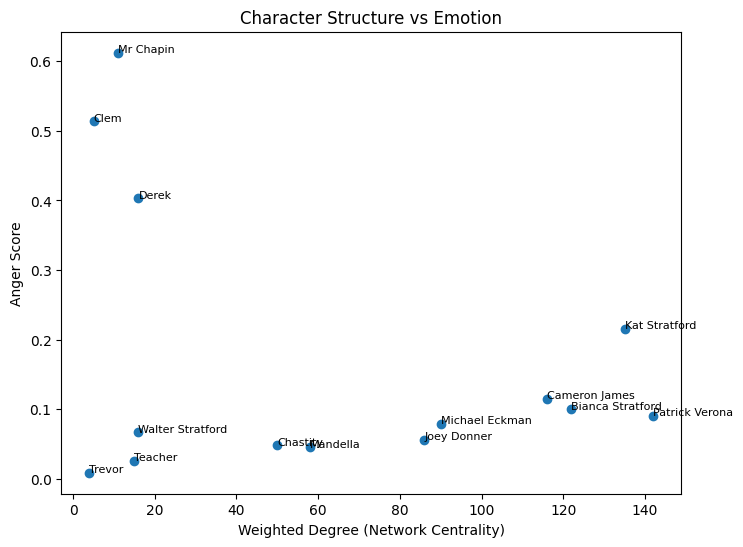

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    final_character_df["weighted_degree"],
    final_character_df["anger"]
)

for _, row in final_character_df.iterrows():
    plt.text(
        row["weighted_degree"],
        row["anger"],
        row["character_name"],
        fontsize=8
    )

plt.xlabel("Weighted Degree (Network Centrality)")
plt.ylabel("Anger Score")
plt.title("Character Structure vs Emotion")

plt.show()

## Conclusion

In this notebook, we moved from structured data to high-level character analysis by integrating:

- interaction networks
- emotional modeling using transformers
- narrative importance metrics

This multi-layered approach allows for a deeper understanding of storytelling dynamics and character behavior.

The results show that meaningful narrative insights can be extracted by combining data science techniques across different domains.

This sets the foundation for the next stage of the project, where we will:

- generalize this approach across multiple movies
- explore clustering of character archetypes
- analyze narrative patterns at scale

In [ ]:
processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

final_character_df.to_parquet(
    processed_dir / "final_character_dataset.parquet",
    index=False
)

print("final_character_dataset.parquet saved successfully.")